In [17]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import os

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
####### Settings #########
# Put ONLY the values you want to simulate right now in this list.
# If you run [10, 30] today, and change this to [50, 100] tomorrow, the code will merge them!
N_train_list = [3,4,5,6,7,8,9,10,15,20,25,30,40,50,75,100,150,200,250,300,400,500,750,1000]  
N_test = 250
num_realizations = 500
num_shots = 0
reg_lambda = 0
filename = "exact_results.json"

# --- LOAD PREVIOUS DATA IF IT EXISTS ---
if os.path.exists(filename):
    print(f"Found existing file '{filename}'. Loading previous data...")
    with open(filename, 'r') as f:
        saved_data = json.load(f)
else:
    print("No previous data found. Starting fresh.")
    saved_data = {'QELM': {}, 'Kernel_LE': {}, 'Kernel_SWAP': {}}

# Filter N_train_list to ONLY calculate values we haven't done yet
# (JSON saves dictionary keys as strings, so we check str(N))
N_train_to_run = [N for N in N_train_list if str(N) not in saved_data['QELM']]

if not N_train_to_run:
    print("All N_train values in the list have already been simulated. Exiting.")
    exit()

print(f"Simulating for N_train = {N_train_to_run}")

N_max = max(N_train_to_run)

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary dictionary for the CURRENT run
mse_runs = {
    'QELM': {N: [] for N in N_train_to_run},
    'Kernel_LE': {N: [] for N in N_train_to_run},
    'Kernel_SWAP': {N: [] for N in N_train_to_run}
}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix 

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    #putting V here, we are assuming that for each realization the input state of
    #the reservoir is the same, and that the only thing that changes is the training/test states
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, num_shots=num_shots
    )

    for N_train in sorted(N_train_to_run, reverse=True):
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # QELM
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(float(np.mean((qelm.predict_vec(rho_test) - y_test)**2)))
        
        # Kernel LE
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(float(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2)))

        # Kernel SWAP
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(float(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2)))

# --- MERGE AND SAVE DATA ---
for model in mse_runs.keys():
    for N_train, mse_list in mse_runs[model].items():
        # JSON requires dictionary keys to be strings
        saved_data[model][str(N_train)] = mse_list

with open(filename, 'w') as f:
    json.dump(saved_data, f, indent=4)

print("="*70)
print(f"Experiment finished and data appended to '{filename}' in {(time.time() - total_time)/60:.1f} minutes.")

No previous data found. Starting fresh.
Simulating for N_train = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 250, 300, 400, 500, 750, 1000]
-------- (Shots = 0, Realizations = 500) --------
Processing Realization 10/500...
Processing Realization 20/500...
Processing Realization 30/500...
Processing Realization 40/500...
Processing Realization 50/500...
Processing Realization 60/500...
Processing Realization 70/500...
Processing Realization 80/500...
Processing Realization 90/500...
Processing Realization 100/500...
Processing Realization 110/500...
Processing Realization 120/500...
Processing Realization 130/500...
Processing Realization 140/500...
Processing Realization 150/500...
Processing Realization 160/500...
Processing Realization 170/500...
Processing Realization 180/500...
Processing Realization 190/500...
Processing Realization 200/500...
Processing Realization 210/500...
Processing Realization 220/500...
Processing Realization 230/500...
Processing R

In [20]:
####### Settings #########
# Put ONLY the values you want to simulate right now in this list.
# If you run [10, 30] today, and change this to [50, 100] tomorrow, the code will merge them!
N_train_list = [3,4,5,6,7,8,9,10,15,20,25,30,40,50,75,100,150,200,250,300,400,500,750,1000]  
N_test = 250
num_realizations = 500
num_shots = 100
reg_lambda = 0
filename = "100_shots_results.json"

# --- LOAD PREVIOUS DATA IF IT EXISTS ---
if os.path.exists(filename):
    print(f"Found existing file '{filename}'. Loading previous data...")
    with open(filename, 'r') as f:
        saved_data = json.load(f)
else:
    print("No previous data found. Starting fresh.")
    saved_data = {'QELM': {}, 'Kernel_LE': {}, 'Kernel_SWAP': {}}

# Filter N_train_list to ONLY calculate values we haven't done yet
# (JSON saves dictionary keys as strings, so we check str(N))
N_train_to_run = [N for N in N_train_list if str(N) not in saved_data['QELM']]

if not N_train_to_run:
    print("All N_train values in the list have already been simulated. Exiting.")
    exit()

print(f"Simulating for N_train = {N_train_to_run}")

N_max = max(N_train_to_run)

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary dictionary for the CURRENT run
mse_runs = {
    'QELM': {N: [] for N in N_train_to_run},
    'Kernel_LE': {N: [] for N in N_train_to_run},
    'Kernel_SWAP': {N: [] for N in N_train_to_run}
}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix 

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    #putting V here, we are assuming that for each realization the input state of
    #the reservoir is the same, and that the only thing that changes is the training/test states
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, num_shots=num_shots
    )

    for N_train in sorted(N_train_to_run, reverse=True):
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # QELM
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(float(np.mean((qelm.predict_vec(rho_test) - y_test)**2)))
        
        # Kernel LE
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(float(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2)))

        # Kernel SWAP
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(float(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2)))

# --- MERGE AND SAVE DATA ---
for model in mse_runs.keys():
    for N_train, mse_list in mse_runs[model].items():
        # JSON requires dictionary keys to be strings
        saved_data[model][str(N_train)] = mse_list

with open(filename, 'w') as f:
    json.dump(saved_data, f, indent=4)

print("="*70)
print(f"Experiment finished and data appended to '{filename}' in {(time.time() - total_time)/60:.1f} minutes.")

No previous data found. Starting fresh.
Simulating for N_train = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 250, 300, 400, 500, 750, 1000]
-------- (Shots = 100, Realizations = 500) --------
Processing Realization 10/500...
Processing Realization 20/500...
Processing Realization 30/500...
Processing Realization 40/500...
Processing Realization 50/500...
Processing Realization 60/500...
Processing Realization 70/500...
Processing Realization 80/500...
Processing Realization 90/500...
Processing Realization 100/500...
Processing Realization 110/500...
Processing Realization 120/500...
Processing Realization 130/500...
Processing Realization 140/500...
Processing Realization 150/500...
Processing Realization 160/500...
Processing Realization 170/500...
Processing Realization 180/500...
Processing Realization 190/500...
Processing Realization 200/500...
Processing Realization 210/500...
Processing Realization 220/500...
Processing Realization 230/500...
Processing

In [ ]:
####### Settings #########
# Put ONLY the values you want to simulate right now in this list.
# If you run [10, 30] today, and change this to [50, 100] tomorrow, the code will merge them!
N_train_list = [3,4,5,6,7,8,9,10,15,20,25,30,40,50,75,100,150,200,250,300,400,500,750,1000]  
N_test = 250
num_realizations = 500
num_shots = 10
reg_lambda = 0
filename = "10_shots_results.json"

# --- LOAD PREVIOUS DATA IF IT EXISTS ---
if os.path.exists(filename):
    print(f"Found existing file '{filename}'. Loading previous data...")
    with open(filename, 'r') as f:
        saved_data = json.load(f)
else:
    print("No previous data found. Starting fresh.")
    saved_data = {'QELM': {}, 'Kernel_LE': {}, 'Kernel_SWAP': {}}

# Filter N_train_list to ONLY calculate values we haven't done yet
# (JSON saves dictionary keys as strings, so we check str(N))
N_train_to_run = [N for N in N_train_list if str(N) not in saved_data['QELM']]

if not N_train_to_run:
    print("All N_train values in the list have already been simulated. Exiting.")
    exit()

print(f"Simulating for N_train = {N_train_to_run}")

N_max = max(N_train_to_run)

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary dictionary for the CURRENT run
mse_runs = {
    'QELM': {N: [] for N in N_train_to_run},
    'Kernel_LE': {N: [] for N in N_train_to_run},
    'Kernel_SWAP': {N: [] for N in N_train_to_run}
}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

# INVERTED LOOP
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    kernel_le_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_le_full.fit_vec(rho_train_full, y_train_full, "le")
    K_matrix_le_full = kernel_le_full.kernel_matrix 

    kernel_swap_full = myQML.QuantumKernelRegression(reg_lambda, num_shots)
    kernel_swap_full.fit_vec(rho_train_full, y_train_full, "swap")
    K_matrix_swap_full = kernel_swap_full.kernel_matrix

    #putting V here, we are assuming that for each realization the input state of
    #the reservoir is the same, and that the only thing that changes is the training/test states
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, num_shots=num_shots
    )

    for N_train in sorted(N_train_to_run, reverse=True):
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        # QELM
        qelm.fit_vec(rho_train_sub, y_train_sub)
        mse_runs['QELM'][N_train].append(float(np.mean((qelm.predict_vec(rho_test) - y_test)**2)))
        
        # Kernel LE
        K_le_sub = K_matrix_le_full[:N_train, :N_train]
        K_le_inv_sub = np.linalg.pinv(K_le_sub, rcond=kernel_le_full.r_cond)
        alpha_le_sub = K_le_inv_sub @ y_train_sub

        kernel_le_full.train_density_matrices = rho_train_sub
        kernel_le_full.train_labels = y_train_sub
        kernel_le_full.kernel_matrix = K_le_sub
        kernel_le_full.K_inv = K_le_inv_sub
        kernel_le_full.alpha = alpha_le_sub
        
        mse_runs['Kernel_LE'][N_train].append(float(np.mean((kernel_le_full.predict_vec(rho_test) - y_test)**2)))

        # Kernel SWAP
        K_swap_sub = K_matrix_swap_full[:N_train, :N_train]
        K_swap_inv_sub = np.linalg.pinv(K_swap_sub, rcond=kernel_swap_full.r_cond)
        alpha_swap_sub = K_swap_inv_sub @ y_train_sub

        kernel_swap_full.train_density_matrices = rho_train_sub
        kernel_swap_full.train_labels = y_train_sub
        kernel_swap_full.kernel_matrix = K_swap_sub
        kernel_swap_full.K_inv = K_swap_inv_sub
        kernel_swap_full.alpha = alpha_swap_sub
        
        mse_runs['Kernel_SWAP'][N_train].append(float(np.mean((kernel_swap_full.predict_vec(rho_test) - y_test)**2)))

# --- MERGE AND SAVE DATA ---
for model in mse_runs.keys():
    for N_train, mse_list in mse_runs[model].items():
        # JSON requires dictionary keys to be strings
        saved_data[model][str(N_train)] = mse_list

with open(filename, 'w') as f:
    json.dump(saved_data, f, indent=4)

print("="*70)
print(f"Experiment finished and data appended to '{filename}' in {(time.time() - total_time)/60:.1f} minutes.")

No previous data found. Starting fresh.
Simulating for N_train = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 250, 300, 400, 500, 750, 1000]
-------- (Shots = 10, Realizations = 500) --------
Processing Realization 10/500...
Processing Realization 20/500...
Processing Realization 30/500...
Processing Realization 40/500...
Processing Realization 50/500...
Processing Realization 60/500...
Processing Realization 70/500...
Processing Realization 80/500...
Processing Realization 90/500...
Processing Realization 100/500...
Processing Realization 110/500...
Processing Realization 120/500...



--- Final Results ---
N = 3    | QELM: 0.1711 | K-LE: 1908.3339 | K-SW: 134.4566
N = 4    | QELM: 0.1561 | K-LE: 51.6547 | K-SW: 99.8508
N = 5    | QELM: 0.1443 | K-LE: 4.3521 | K-SW: 227.8214
N = 6    | QELM: 0.1361 | K-LE: 51.0377 | K-SW: 121.4691
N = 7    | QELM: 0.1281 | K-LE: 11.5072 | K-SW: 558.2522
N = 8    | QELM: 0.1212 | K-LE: 138.1963 | K-SW: 146.3622
N = 9    | QELM: 0.1147 | K-LE: 32461.6183 | K-SW: 856.1850
N = 10   | QELM: 0.1100 | K-LE: 121.5657 | K-SW: 35.6952
N = 15   | QELM: 0.0946 | K-LE: 48.0762 | K-SW: 752.3222
N = 20   | QELM: 0.0878 | K-LE: 3.5751 | K-SW: 43.2832
N = 25   | QELM: 0.0877 | K-LE: 9.6742 | K-SW: 229.5643
N = 30   | QELM: 0.0944 | K-LE: 4.6238 | K-SW: 678.9368
N = 40   | QELM: 0.1233 | K-LE: 9.3887 | K-SW: 461.6931
N = 50   | QELM: 0.2015 | K-LE: 294.5832 | K-SW: 104.1631
N = 75   | QELM: 0.2853 | K-LE: 741.1553 | K-SW: 351.8710
N = 100  | QELM: 0.1093 | K-LE: 9.4366 | K-SW: 339.9671
N = 150  | QELM: 0.0684 | K-LE: 16.2338 | K-SW: 56.9694
N = 200  

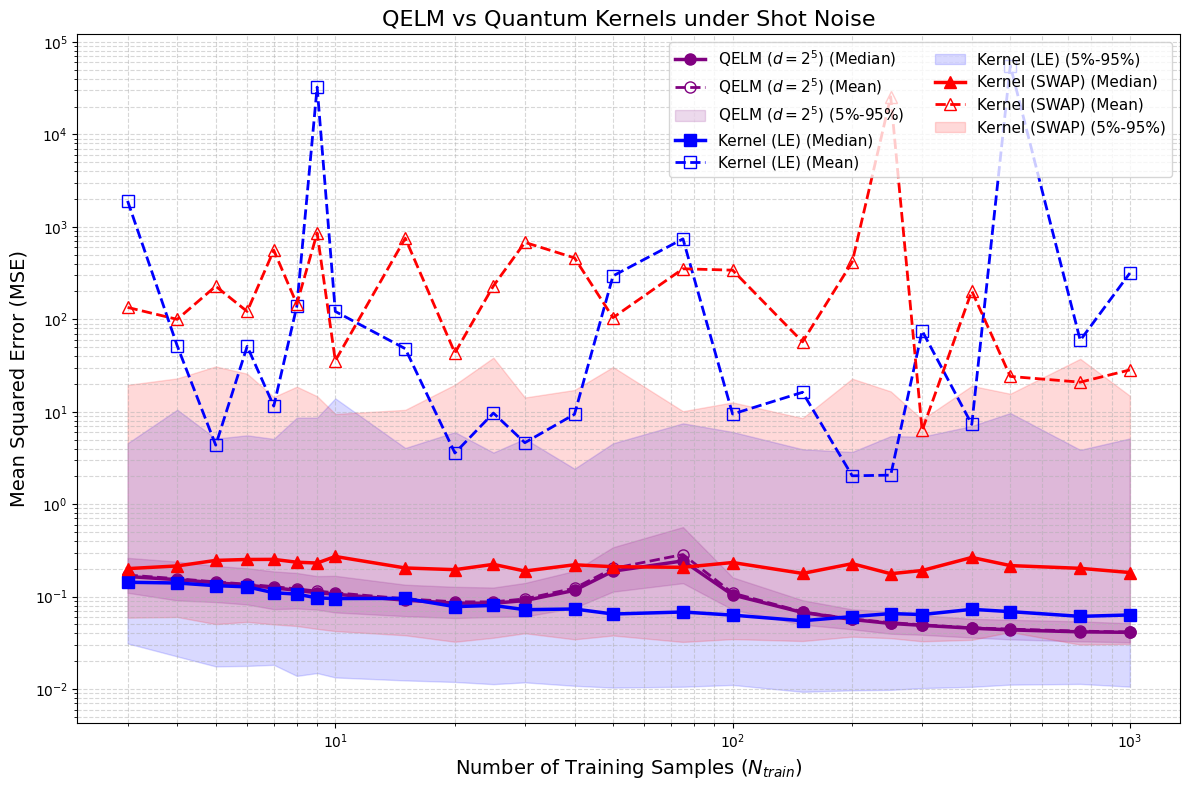

In [22]:
import json
import numpy as np
import matplotlib.pyplot as plt

filename = "100_shots_results.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract the N_train values present in the file and sort them numerically
# (We convert them back from strings to integers)
N_train_list = sorted([int(k) for k in data['QELM'].keys()])
N_arr = np.array(N_train_list)

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

# 2. Compute statistics
print("\n--- Final Results ---")
for N_train in N_train_list:
    str_N = str(N_train) # JSON keys are strings
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        mse_array = np.array(data[model][str_N])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))
        
    print(f"N = {N_train:<4d} | QELM: {results_mean['QELM'][-1]:.4f} | K-LE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW: {results_mean['Kernel_SWAP'][-1]:.4f}")

# 3. Plotting
plt.figure(figsize=(12, 8))

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 'Kernel_LE': 'Kernel (LE)', 'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Median
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Mean
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8, fillstyle='none')
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()
plt.show()